# Un robot de cuatro patas corrió una maratón con una sola batería

**4 horas, 19 minutos y 52 segundos.** Eso tardó RAIBO2, un robot cuadrúpedo de 43 a 45 kg, en
completar los 42,195 km de una maratón oficial. Sin cambiar de batería.

¿Cuánta energía cuesta eso? ¿Y cuánta le quedó al cruzar la meta?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Lee et al. (2026), *Nature* — «A quadruped robot designed to complete a marathon on a
single battery charge»
**DOI:** [10.1038/s41586-026-11102-5](https://doi.org/10.1038/s41586-026-11102-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-23-robot-cuadrupedo-maraton-una-carga/notebook.ipynb)

**Video:** [Pendiente]

El 17 de noviembre de 2024, RAIBO2 corrió la 22.ª Maratón Gotgam de Sangju, en Corea del Sur. Los
robots con patas gastan energía sin parar: sostienen su peso con los motores de las articulaciones y
pierden energía en cada pisada. Para bajar ese gasto, el equipo rediseñó tres piezas a la vez: una
mecánica ligera que transmite la fuerza casi sin pérdidas (*force-transparent*), un circuito de
motores de baja resistencia y una política de control (el programa que decide cómo mover cada pata) que disipa poca energía.

La vara de medir es el **coste de transporte** (COT, *cost of transport*): energía gastada por cada
kilo de peso y cada metro recorrido. Cuanto más bajo, más eficiente. Tenemos la telemetría de la
batería segundo a segundo, el GPS de la carrera y la tabla comparativa del propio paper.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
MASA_KG = 43.0            # Extended Data Table 1: 43,0 kg (batería 20s6p) — o 45,0 kg (16s10p)
BATERIA_WH = 1447         # capacidad de la batería (Supplementary Data 1)
G = 9.8                   # gravedad usada en la fórmula del Supplementary Data 1
DIST_OFICIAL_KM = 42.195  # distancia de una maratón
TIEMPO_OFICIAL_S = 15592  # 4 h 19 min 52 s (tiempo oficial del paper)
T_SALIDA, T_META = 100, 15720   # ventana salida→meta en el reloj del GPS (s)
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_GRIS = '#BBBBBB'
FUENTE = ('Fuente: Lee et al. (2026), Nature | Datos: Zenodo 10.5281/zenodo.14825866 '
          '(telemetría y GPS) y Supplementary Data 1')

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo editorial CaM (local → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga (descarga desde el repo si no están en local) ──────
os.makedirs('datos', exist_ok=True)
for f in ['telemetria_robot_1hz.csv', 'recorrido_gps.csv', 'cot_comparativa.csv']:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/{os.path.basename(os.getcwd())}/datos/{f}', f'datos/{f}')
tel = pd.read_csv('datos/telemetria_robot_1hz.csv')   # batería y motores, 1 fila por segundo
gps = pd.read_csv('datos/recorrido_gps.csv')          # reloj GPS, 1 punto por segundo
cot = pd.read_csv('datos/cot_comparativa.csv')        # Supplementary Data 1: robots, animales, autos

# ── Solo la carrera: de la salida a la meta ──────────────────
car = tel[tel['fase'] == 'carrera'].copy()
car['h'] = (car['t_gpx_s'] - T_SALIDA) / 3600          # horas desde la salida
car['E_acum_wh'] = car['potencia_w'].cumsum() / 3600  # 1 fila = 1 s → W·s / 3600 = Wh
E_CARRERA = car['potencia_w'].sum() / 3600
E_POR_FASE = tel.groupby('fase')['potencia_w'].sum() / 3600

# Coste de transporte, fórmula literal del Supplementary Data 1: E[Wh]·3,6 / d[km] / m[kg] / g
cot_carrera = E_CARRERA * 3.6 / DIST_OFICIAL_KM / MASA_KG / G

tramo = gps[(gps['t_s'] >= T_SALIDA) & (gps['t_s'] <= T_META)]
dist_gps = tramo['dist_acum_m'].iloc[-1] - tramo['dist_acum_m'].iloc[0]

print(f'Telemetría: {len(tel):,} s registrados; {len(car):,} s entre salida y meta')
print(f'Energía salida→meta: {E_CARRERA:,.1f} Wh = {E_CARRERA / BATERIA_WH:.1%} de la batería')
print(f'   (antes de la salida {E_POR_FASE["antes"]:.1f} Wh, después de la meta {E_POR_FASE["despues"]:.1f} Wh)')
print(f'Velocidad media oficial: {DIST_OFICIAL_KM / TIEMPO_OFICIAL_S * 3600:.2f} km/h')
print(f'Distancia GPS salida→meta: {dist_gps:,.0f} m ({dist_gps / 42195 - 1:+.1%} vs 42.195 m)')
print(f'COT recalculado ({MASA_KG:.0f} kg): {cot_carrera:.3f}  |  paper: 0,248  ({cot_carrera / 0.248 - 1:+.1%})')
E_TOTAL = tel['potencia_w'].sum() / 3600
print(f'Variantes: con 45 kg → {E_CARRERA * 3.6 / DIST_OFICIAL_KM / 45.0 / G:.3f} | con toda la energía registrada '
      f'({E_TOTAL:,.1f} Wh = {E_TOTAL / BATERIA_WH:.1%} de la batería) → {E_TOTAL * 3.6 / DIST_OFICIAL_KM / MASA_KG / G:.3f}')
print(f'Distancia por odometría del robot (salida→meta): {car["rapidez_odometria_mps"].sum() / 1000:.1f} km')

Telemetría: 17,755 s registrados; 15,604 s entre salida y meta
Energía salida→meta: 1,241.6 Wh = 85.8% de la batería
   (antes de la salida 17.3 Wh, después de la meta 48.5 Wh)
Velocidad media oficial: 9.74 km/h
Distancia GPS salida→meta: 42,107 m (-0.2% vs 42.195 m)
COT recalculado (43 kg): 0.251  |  paper: 0,248  (+1.4%)
Variantes: con 45 kg → 0.240 | con toda la energía registrada (1,307.4 Wh = 90.4% de la batería) → 0.265
Distancia por odometría del robot (salida→meta): 38.9 km


Aquí está.

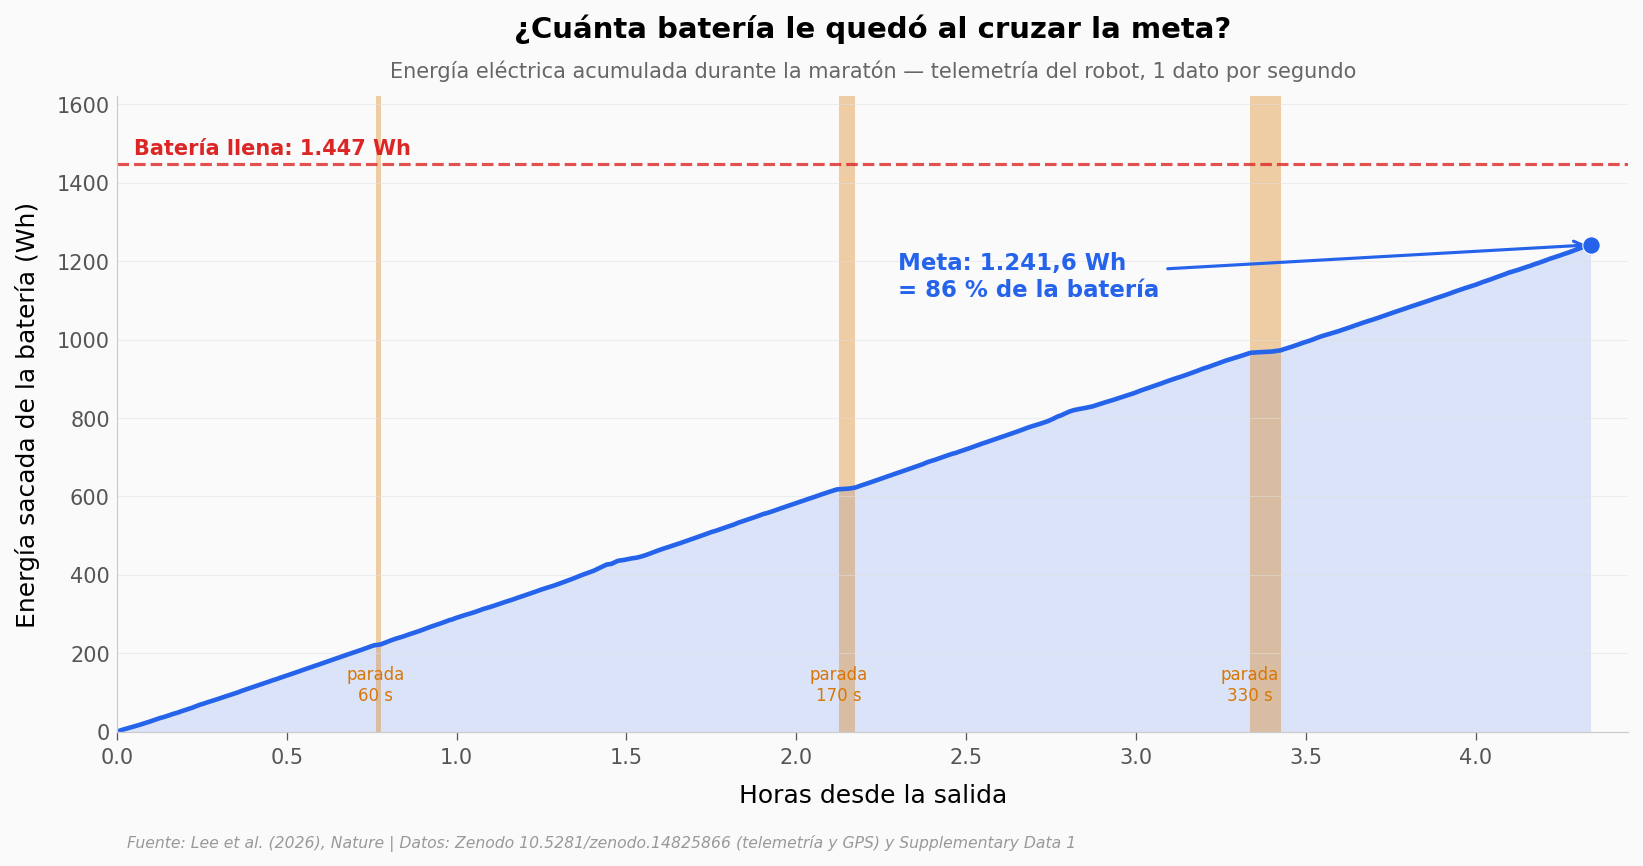

Potencia en carrera: media 286.5 W, mediana 277.9 W, IQR 212.9–352.7 W, asimetría 0.40
Paradas ≥ 60 s (inicio en s del GPS, duración): [(2840, 60), (7750, 170), (12110, 330)]


In [2]:
# Paradas: ventanas de 10 s del GPS con menos de 3 m recorridos, encadenadas ≥ 60 s
g10 = gps.assign(b=gps['t_s'] // 10 * 10).groupby('b')['dist_acum_m'].agg(lambda s: s.iloc[-1] - s.iloc[0])
paradas, ini = [], None
for b, quieto in (g10 < 3).items():
    if quieto and ini is None:
        ini = b
    elif not quieto and ini is not None:
        if b - ini >= 60 and T_SALIDA <= ini <= T_META:
            paradas.append((ini, b - ini))
        ini = None

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.fill_between(car['h'], car['E_acum_wh'], color=COLOR_DATOS, alpha=0.15, linewidth=0)
ax.plot(car['h'], car['E_acum_wh'], color=COLOR_DATOS, linewidth=2.2)
ax.axhline(BATERIA_WH, color=COLOR_ALERTA, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(0.05, BATERIA_WH + 25, f'Batería llena: {BATERIA_WH:,} Wh'.replace(',', '.'),
        color=COLOR_ALERTA, fontsize=10, fontweight='bold')
for t0, dur in paradas:
    ax.axvspan((t0 - T_SALIDA) / 3600, (t0 + dur - T_SALIDA) / 3600, color=COLOR_REFERENCIA, alpha=0.35, linewidth=0)
    ax.text((t0 - T_SALIDA) / 3600, 80, f'parada\n{dur} s', fontsize=8, color=COLOR_REFERENCIA, ha='center')
h_fin, e_fin = car['h'].iloc[-1], car['E_acum_wh'].iloc[-1]
ax.scatter([h_fin], [e_fin], color=COLOR_DATOS, s=70, zorder=6, edgecolors='white')
ax.annotate(f'Meta: {e_fin:,.1f} Wh'.replace(',', 'X').replace('.', ',').replace('X', '.')
            + f'\n= {e_fin / BATERIA_WH * 100:.0f} % de la batería',
            xy=(h_fin, e_fin), xytext=(2.3, 1110), fontsize=11, fontweight='bold',
            color=COLOR_DATOS, arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))
ax.set_xlim(0, 4.45)
ax.set_ylim(0, BATERIA_WH * 1.12)
ax.set_xlabel('Horas desde la salida')
ax.set_ylabel('Energía sacada de la batería (Wh)')
ax.set_title('¿Cuánta batería le quedó al cruzar la meta?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Energía eléctrica acumulada durante la maratón — telemetría del robot, 1 dato por segundo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/energia_acumulada.png', dpi=200, bbox_inches='tight')
plt.show()

p = car['potencia_w']
print(f'Potencia en carrera: media {p.mean():.1f} W, mediana {p.median():.1f} W, '
      f'IQR {p.quantile(.25):.1f}–{p.quantile(.75):.1f} W, asimetría {p.skew():.2f}')
print('Paradas ≥ 60 s (inicio en s del GPS, duración):', paradas)

Al cruzar la meta, el robot había sacado 1.241,6 Wh de la batería: el 86 % de la carga. El gasto
sube a un ritmo casi constante —una media de 286,5 W, con la mitad central de los segundos entre
212,9 y 352,7 W— y solo se frena en tres paradas de más de un minuto (60, 170 y 330 segundos).

Parado tampoco sale gratis: en los 640 segundos en que la odometría del robot (lo que el robot calcula que avanzó con sus
propios sensores) marca casi cero (menos de 0,3 m/s), la potencia media fue de 92,7 W. Sostenerse en pie cuesta.

Las dos paradas largas caen justo donde se corta el registro de datos (hay tres archivos). El
material que pudimos leer no dice por qué se detuvo.

¿Y cómo sabemos que fue **una** batería? Si alguien la hubiera cambiado en una parada, el voltaje
saltaría de golpe hacia arriba. Veamos el voltaje y el ritmo cada 5 km.

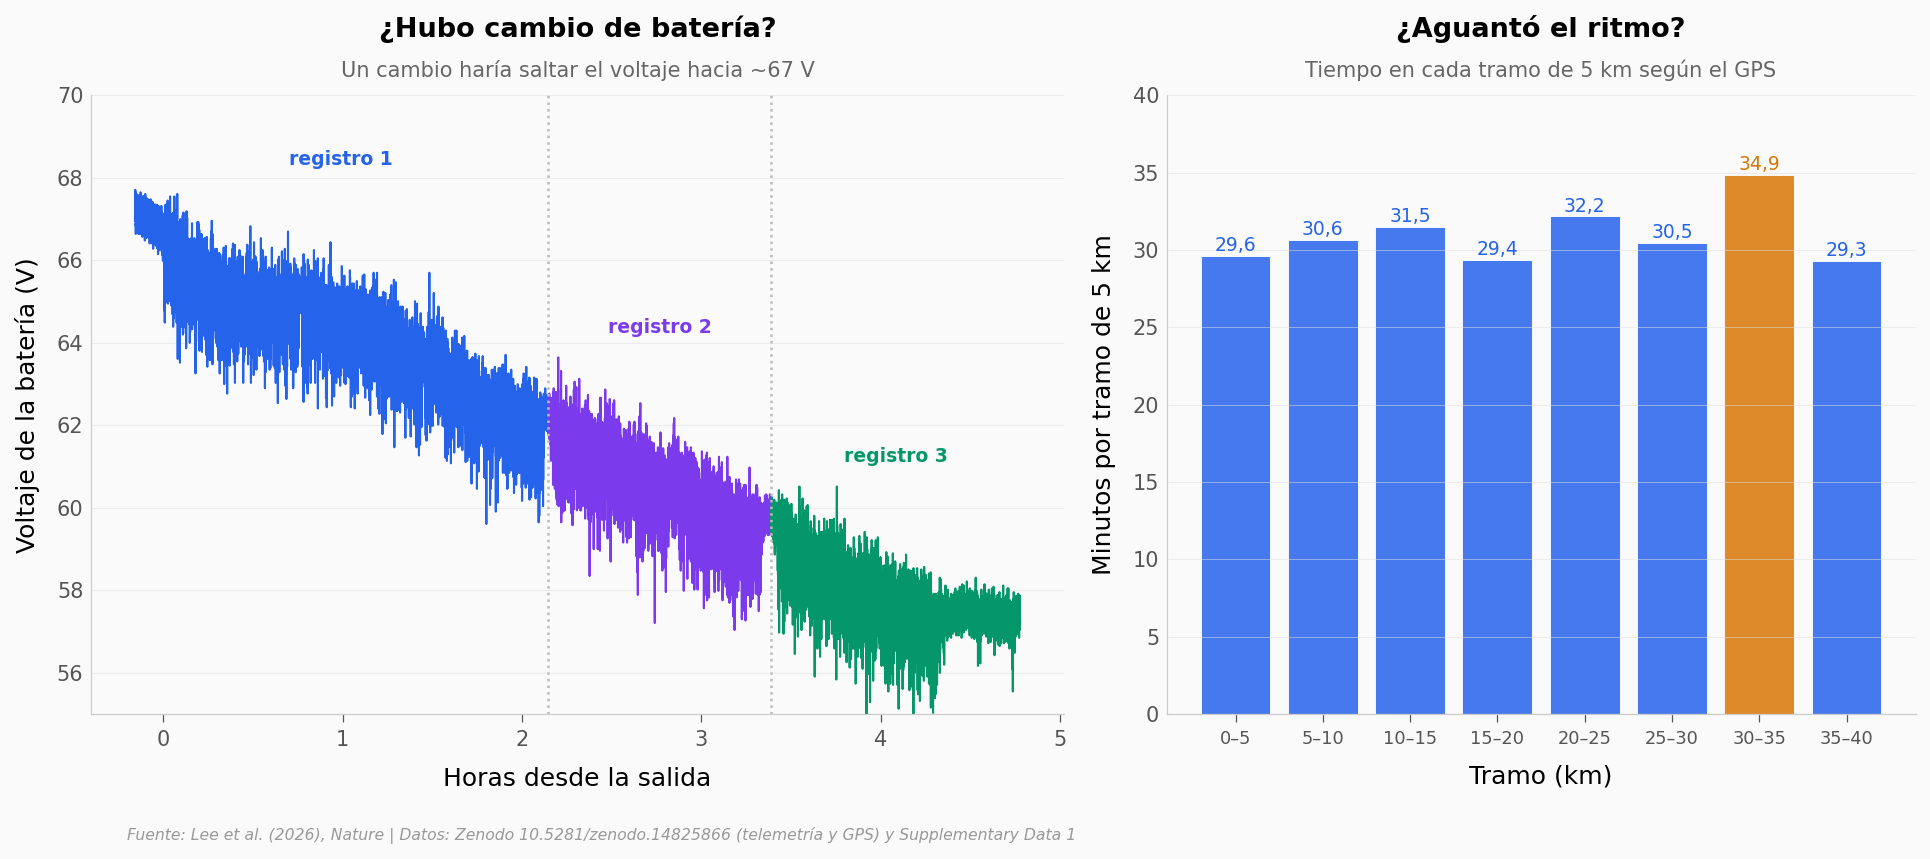

Voltaje: 67.03 V al inicio → 57.21 V al final
Voltaje en cada corte de registro (antes → después): [(62.12, 62.05), (59.52, 60.0)]
Parciales de 5 km (min): ['29.6', '30.6', '31.5', '29.4', '32.2', '30.5', '34.9', '29.3'] | rango 29.3–34.9
Potencia media por hora de carrera (W): [290.3, 292.6, 283.3, 274.7, 301.1] | segundos: [3600, 3599, 3586, 3599, 1220]
Temperatura máxima de motor: 57 °C | aire: 15–19 °C


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={'width_ratios': [1.3, 1]})

# Voltaje de toda la sesión, coloreado por archivo de registro
colores_log = {1: COLOR_DATOS, 2: '#7C3AED', 3: COLOR_SECUNDARIO}
for lg, d in tel.groupby('log'):
    ax1.plot((d['t_gpx_s'] - T_SALIDA) / 3600, d['voltaje_v'], color=colores_log[lg], linewidth=1)
    ax1.text((d['t_gpx_s'].iloc[len(d) // 2] - T_SALIDA) / 3600, d['voltaje_v'].max() + 0.6,
             f'registro {lg}', color=colores_log[lg], fontsize=9, fontweight='bold', ha='center')
saltos = []
for lg in (1, 2):
    a, b = tel[tel['log'] == lg].iloc[-1], tel[tel['log'] == lg + 1].iloc[0]
    saltos.append((float(a['voltaje_v']), float(b['voltaje_v'])))
    ax1.axvline((b['t_gpx_s'] - T_SALIDA) / 3600, color=COLOR_GRIS, linestyle=':', linewidth=1.2)
ax1.set_xlabel('Horas desde la salida')
ax1.set_ylabel('Voltaje de la batería (V)')
ax1.set_ylim(55, 70)
ax1.set_title('¿Hubo cambio de batería?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Un cambio haría saltar el voltaje hacia ~67 V',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

# Parciales cada 5 km (GPS, desde la salida)
dd = tramo['dist_acum_m'] - tramo['dist_acum_m'].iloc[0]
marcas = [T_SALIDA] + [tramo['t_s'][dd >= k * 5000].iloc[0] for k in range(1, 9)]
splits = np.diff(marcas) / 60
etiquetas = [f'{5 * (k - 1)}–{5 * k}' for k in range(1, 9)]
cols = [COLOR_REFERENCIA if s == splits.max() else COLOR_DATOS for s in splits]
ax2.bar(range(8), splits, color=cols, alpha=0.85, edgecolor='white')
for i, s in enumerate(splits):
    ax2.text(i, s + 0.3, f'{s:.1f}'.replace('.', ','), ha='center', fontsize=9, color=cols[i])
ax2.set_xticks(range(8))
ax2.set_xticklabels(etiquetas, fontsize=8.5)
ax2.set_xlabel('Tramo (km)')
ax2.set_ylabel('Minutos por tramo de 5 km')
ax2.set_ylim(0, 40)
ax2.set_title('¿Aguantó el ritmo?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Tiempo en cada tramo de 5 km según el GPS',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.07, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/voltaje_y_parciales.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Voltaje: {tel["voltaje_v"].iloc[0]:.2f} V al inicio → {tel["voltaje_v"].iloc[-1]:.2f} V al final')
print('Voltaje en cada corte de registro (antes → después):', saltos)
print('Parciales de 5 km (min):', [f'{s:.1f}' for s in splits], f'| rango {splits.min():.1f}–{splits.max():.1f}')
por_hora = car.assign(hora=(car['h'] // 1).astype(int)).groupby('hora')['potencia_w'].agg(['mean', 'size'])
print('Potencia media por hora de carrera (W):', por_hora['mean'].round(1).tolist(), '| segundos:', por_hora['size'].tolist())
print(f'Temperatura máxima de motor: {tel["temp_motor_max_c"].max()} °C | aire: '
      f'{gps["temp_aire_c"].min():.0f}–{gps["temp_aire_c"].max():.0f} °C')

El voltaje baja de 67,0 V a 57,2 V sin un solo salto de vuelta a la carga completa. En los dos
cortes de registro pasa de 62,12 a 62,05 V y de 59,52 a 60,00 V: ese medio voltio de subida en el segundo corte encaja con lo
que recupera una batería tras 5,5 minutos en reposo; un recambio la devolvería a unos 67 V.

El ritmo es parejo: cada tramo de 5 km le tomó entre 29,3 y 34,9 minutos, y el más lento incluye la
parada de 330 segundos. La potencia media por hora se mantiene entre 274,7 y 301,1 W: 290,3 W la
primera hora, 274,7 W la cuarta y 301,1 W en los últimos 20 minutos. Los motores no pasaron de 57 °C, con el aire entre 15 y 19 °C.

Ahora el número del titular. Con la fórmula del material suplementario del paper (Supplementary Data 1) y solo la energía de la
salida a la meta, nos sale un coste de transporte de 0,251. El paper reporta 0,248: coincidimos a
un 1,4 %.

¿Es mucho o poco? Pongámoslo junto a los otros robots, animales y autos de la tabla del paper.

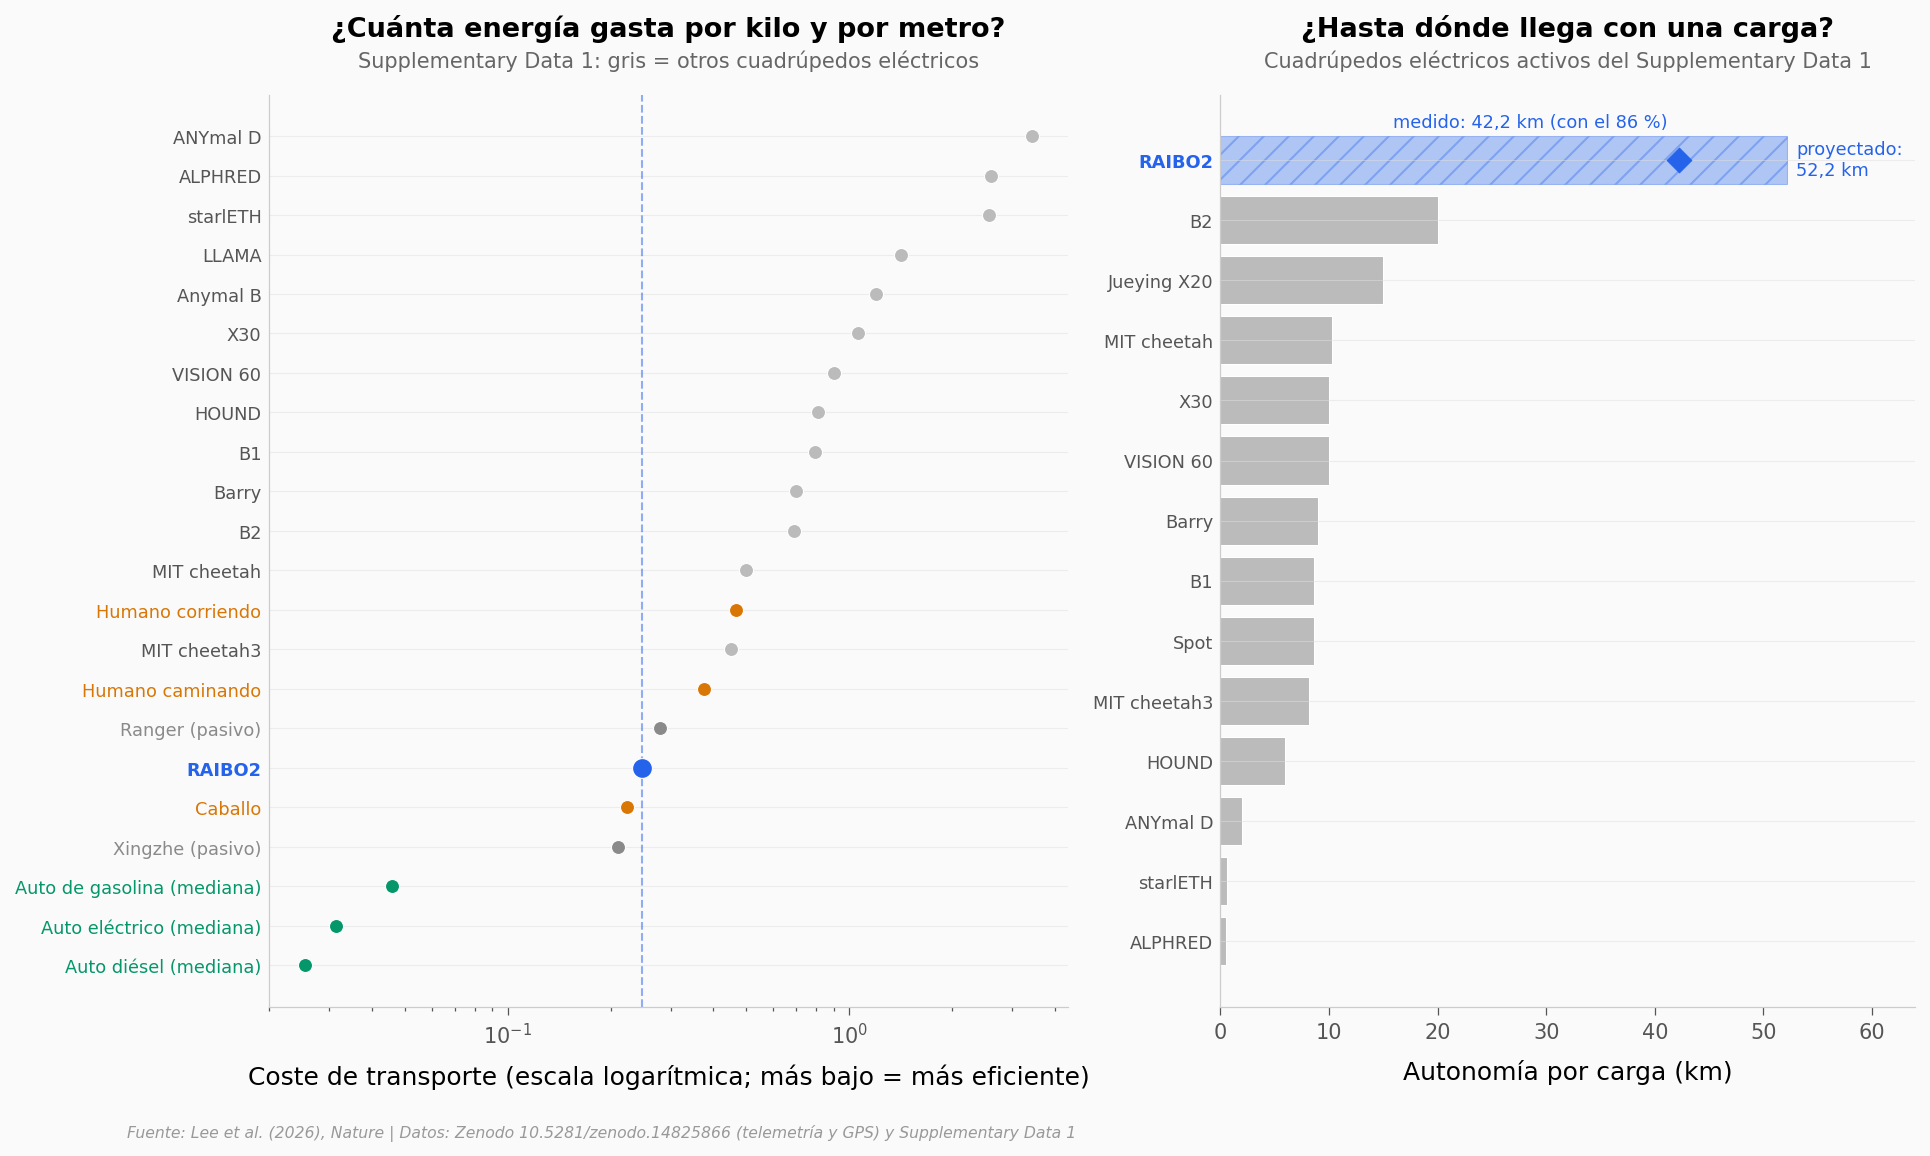

Otros cuadrúpedos eléctricos con COT: n=13, mediana 0.90, mejor MIT cheetah3 0.45
Caminantes pasivos: {'Ranger': 0.28, 'Xingzhe': 0.21}  velocidades (m/s): [0.59, 0.68]
Humano caminando 0.377 | corriendo 0.467 | caballo 0.223
Autos (mediana): {'vehiculo_diesel': 0.025, 'vehiculo_electrico': 0.031, 'vehiculo_gasolina': 0.046} | RAIBO2 / auto: {'vehiculo_diesel': 9.7, 'vehiculo_electrico': 7.9, 'vehiculo_gasolina': 5.4}
Mejor otro / RAIBO2: 1.81×
Autonomía: RAIBO2 52.2 km (proyección) vs mejor otro B2 20 km = 2.61×; vs 2.º Jueying X20 15 km = 3.48×
Supera >3× a 12 de 13 cuadrúpedos eléctricos con autonomía
Potencia implícita en la proyección de 52,2 km a 3 m/s: 299.4 W
Fuera de la comparación (pasivos e hidráulicos): {'BigDog': 10.0, 'LS3': 32.2, 'Ranger': 65.0, 'Xingzhe': 134.0}


In [4]:
elec = cot[(cot['grupo'] == 'robot_cuadrupedo') & (cot['tipo'] == 'Elec robot') & (cot['nombre'] != 'Raibo2')]
pdw = cot[cot['tipo'] == 'Elec(PDW) robot']       # caminantes de dinámica pasiva
raibo = cot[cot['nombre'] == 'Raibo2'].iloc[0]
hum = cot[cot['nombre'] == 'human'].set_index('tipo')['cot']
caballo = cot.loc[cot['nombre'].str.lower() == 'horse', 'cot']
autos = cot[cot['grupo'].str.startswith('vehiculo')].groupby('grupo')['cot'].median()

filas = [(n, c, COLOR_GRIS) for n, c in elec.dropna(subset=['cot'])[['nombre', 'cot']].values]
filas += [(f'{n} (pasivo)', c, '#8A8A8A') for n, c in pdw[['nombre', 'cot']].values]
filas += [('RAIBO2', raibo['cot'], COLOR_DATOS),
          ('Humano caminando', hum['walking'], COLOR_REFERENCIA),
          ('Humano corriendo', hum['running'], COLOR_REFERENCIA)]
if len(caballo):
    filas.append(('Caballo', caballo.iloc[0], COLOR_REFERENCIA))
nombres_auto = {'vehiculo_electrico': 'Auto eléctrico', 'vehiculo_diesel': 'Auto diésel',
                'vehiculo_gasolina': 'Auto de gasolina'}
filas += [(nombres_auto[k] + ' (mediana)', v, COLOR_SECUNDARIO) for k, v in autos.items()]
filas.sort(key=lambda r: r[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7.5), gridspec_kw={'width_ratios': [1.15, 1]})
for i, (n, c, col) in enumerate(filas):
    ax1.scatter(c, i, color=col, s=90 if n == 'RAIBO2' else 45, zorder=5, edgecolors='white', linewidths=0.5)
ax1.set_yticks(range(len(filas)))
ax1.set_yticklabels([r[0] for r in filas], fontsize=8.5)
for tick, r in zip(ax1.get_yticklabels(), filas):
    tick.set_color(r[2] if r[2] != COLOR_GRIS else '#555555')
    if r[0] == 'RAIBO2':
        tick.set_fontweight('bold')
ax1.set_xscale('log')
ax1.axvline(raibo['cot'], color=COLOR_DATOS, linewidth=1, linestyle='--', alpha=0.5)
ax1.set_xlabel('Coste de transporte (escala logarítmica; más bajo = más eficiente)')
ax1.set_title('¿Cuánta energía gasta por kilo y por metro?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Supplementary Data 1: gris = otros cuadrúpedos eléctricos',
         transform=ax1.transAxes, fontsize=10, color='#666666', ha='center')

aut = elec.dropna(subset=['autonomia_km']).sort_values('autonomia_km')
ax2.barh(range(len(aut)), aut['autonomia_km'], color=COLOR_GRIS, edgecolor='white')
y_r = len(aut)
ax2.barh(y_r, raibo['autonomia_km'], color=COLOR_DATOS, alpha=0.35, hatch='//', edgecolor=COLOR_DATOS)
ax2.scatter(DIST_OFICIAL_KM, y_r, color=COLOR_DATOS, s=70, marker='D', zorder=6)
ax2.text(DIST_OFICIAL_KM - 1, y_r + 0.55, 'medido: 42,2 km (con el 86 %)', fontsize=8.5,
         color=COLOR_DATOS, ha='right')
ax2.text(raibo['autonomia_km'] + 0.8, y_r, 'proyectado:\n52,2 km', fontsize=8.5, color=COLOR_DATOS, va='center')
ax2.set_yticks(range(len(aut) + 1))
ax2.set_yticklabels(list(aut['nombre']) + ['RAIBO2'], fontsize=8.5)
ax2.get_yticklabels()[-1].set_color(COLOR_DATOS)
ax2.get_yticklabels()[-1].set_fontweight('bold')
ax2.set_xlim(0, 64)
ax2.set_xlabel('Autonomía por carga (km)')
ax2.set_title('¿Hasta dónde llega con una carga?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Cuadrúpedos eléctricos activos del Supplementary Data 1',
         transform=ax2.transAxes, fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.07, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cot_y_autonomia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Otros cuadrúpedos eléctricos con COT: n={elec["cot"].notna().sum()}, mediana {elec["cot"].median():.2f}, '
      f'mejor {elec.loc[elec["cot"].idxmin(), "nombre"]} {elec["cot"].min():.2f}')
print(f'Caminantes pasivos: {dict(zip(pdw["nombre"], pdw["cot"]))}  velocidades (m/s): {pdw["velocidad_mps"].tolist()}')
print(f'Humano caminando {hum["walking"]:.3f} | corriendo {hum["running"]:.3f} | caballo '
      f'{caballo.iloc[0] if len(caballo) else float("nan"):.3f}')
print('Autos (mediana):', autos.round(3).to_dict(), '| RAIBO2 / auto:', (raibo['cot'] / autos).round(1).to_dict())
print(f'Mejor otro / RAIBO2: {elec["cot"].min() / raibo["cot"]:.2f}×')
b2 = aut.iloc[-1]
print(f'Autonomía: RAIBO2 {raibo["autonomia_km"]:.1f} km (proyección) vs mejor otro {b2["nombre"]} '
      f'{b2["autonomia_km"]:.0f} km = {raibo["autonomia_km"] / b2["autonomia_km"]:.2f}×; '
      f'vs 2.º {aut.iloc[-2]["nombre"]} {aut.iloc[-2]["autonomia_km"]:.0f} km = '
      f'{raibo["autonomia_km"] / aut.iloc[-2]["autonomia_km"]:.2f}×')
print(f'Supera >3× a {(raibo["autonomia_km"] > 3 * aut["autonomia_km"]).sum()} de {len(aut)} cuadrúpedos eléctricos con autonomía')
print(f'Potencia implícita en la proyección de 52,2 km a 3 m/s: {BATERIA_WH / (raibo["autonomia_km"] / 3.0 / 3.6):.1f} W')
otros = cot[cot['tipo'].isin(['Elec(PDW) robot', 'Hydr robot'])].dropna(subset=['autonomia_km'])
print('Fuera de la comparación (pasivos e hidráulicos):', dict(zip(otros['nombre'], otros['autonomia_km'])))

Entre los 13 cuadrúpedos eléctricos activos con COT en la tabla, la mediana es de 0,90 y el mejor,
MIT Cheetah 3, marca 0,45: 1,8 veces lo que gasta RAIBO2 (0,248 en esa tabla). Solo un cuadrúpedo baja
más: Xingzhe (0,21); otro, Ranger, queda cerca (0,28). Los dos son caminantes de dinámica pasiva
(*passive dynamic walkers*) que avanzan a menos de 0,7 m/s; RAIBO2 promedió 9,74 km/h (2,71 m/s). Y un caballo (0,223) sigue por delante.

El abstract dice que RAIBO2 supera «la referencia humana de 0,37». Ese número coincide con el de un
humano **caminando** en la tabla (0,377); corriendo, el humano sube a 0,467. Ojo: el COT humano es metabólico y el del robot es
eléctrico, a la salida de la batería. Miden energía por kilo y por metro, pero en puntos distintos
de la cadena. Los autos, en cambio, siguen muy por delante: entre 5 y 10 veces más eficientes (medianas de 0,025 a 0,046).

Sobre la autonomía, según los autores RAIBO2 ofrece «más de tres veces» el alcance por carga de los
cuadrúpedos existentes. Con la tabla publicada, sus 52,2 km proyectados son 2,61 veces los del mejor cuadrúpedo eléctrico
activo (B2, 20 km) y más del triple que los de 12 de esos 13. Los dos caminantes pasivos llegan más
lejos (65 y 134 km) y el hidráulico LS3 declara 32,2 km. Esos 52,2 km son una proyección
(la energía de la batería dividida entre 299,4 W, a 3 m/s); lo medido son los 42,195 km de la maratón con el 86 % de la carga.

¿Qué tan parejo fue el esfuerzo? Un robot que corre a tirones gastaría a picos; uno que mantiene el paso,
a un ritmo estable. Miremos los 15.604 segundos de carrera, uno por uno.

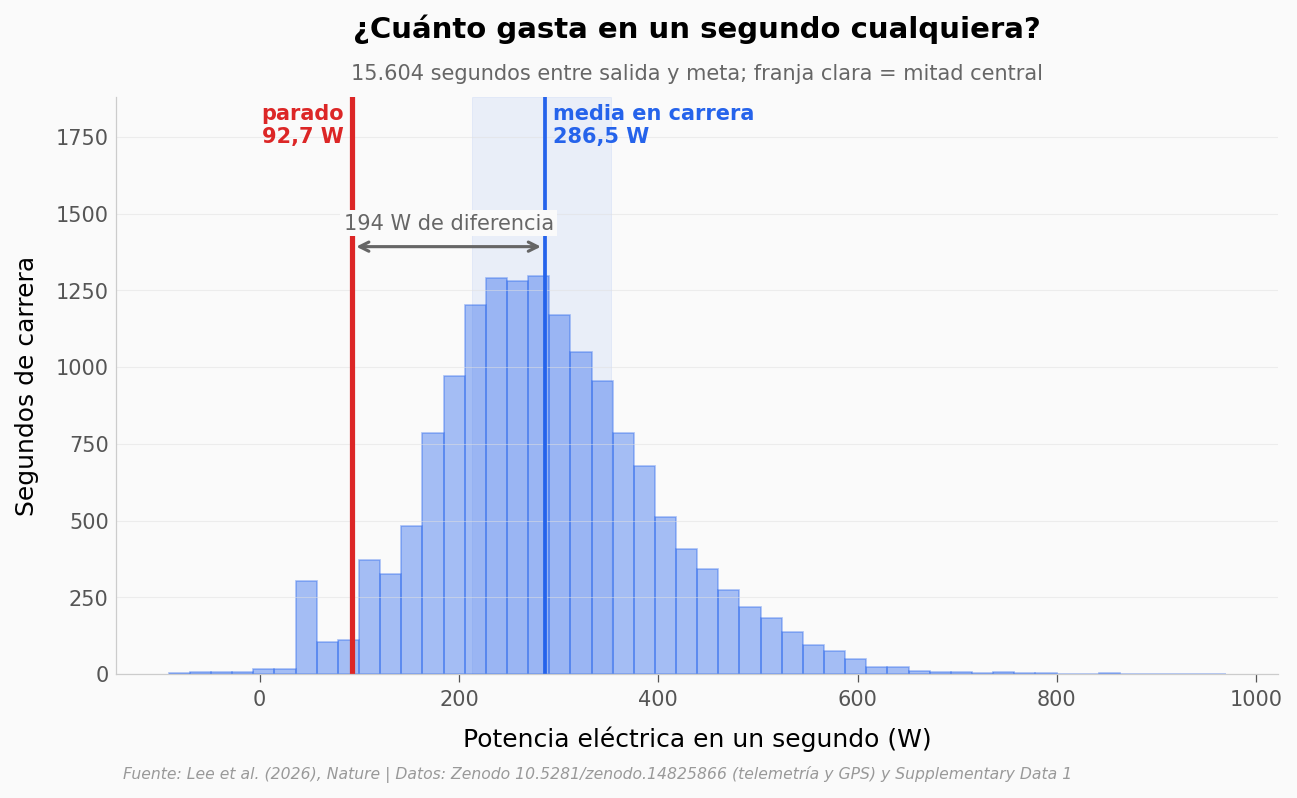

n = 15604 s | media 286.5 W | mediana 277.9 W | IQR 212.9–352.7 W | asimetría 0.40
Parado (odometría < 0,3 m/s): 640 s, media 92.7 W
Segundos por debajo de 120 W: 932; de ellos, parado (GPS u odometría): 596


In [5]:
p = car['potencia_w']
parado = car.loc[car['rapidez_odometria_mps'] < 0.3, 'potencia_w']

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(p, bins=50, color=COLOR_DATOS, alpha=0.4, edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.45
ax.set_ylim(0, y_max)
ax.axvspan(p.quantile(.25), p.quantile(.75), color=COLOR_DATOS, alpha=0.08)
ax.axvline(p.mean(), color=COLOR_DATOS, linewidth=1.8)
ax.axvline(parado.mean(), color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(parado.mean(), y_max * 0.74), xytext=(p.mean(), y_max * 0.74),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((p.mean() + parado.mean()) / 2, y_max * 0.77, f'{p.mean() - parado.mean():.0f} W de diferencia',
        ha='center', fontsize=10, color='#666666', zorder=8,
        bbox=dict(facecolor='#FAFAFA', edgecolor='none', pad=1.5))
ax.text(p.mean() + 8, y_max * 0.92, f'media en carrera\n{p.mean():.1f} W'.replace('.', ','),
        color=COLOR_DATOS, fontsize=10, fontweight='bold')
ax.text(parado.mean() - 8, y_max * 0.92, f'parado\n{parado.mean():.1f} W'.replace('.', ','),
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', ha='right')
ax.set_xlabel('Potencia eléctrica en un segundo (W)')
ax.set_ylabel('Segundos de carrera')
ax.set_title('¿Cuánto gasta en un segundo cualquiera?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{len(p):,} segundos entre salida y meta; franja clara = mitad central'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_potencia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'n = {len(p)} s | media {p.mean():.1f} W | mediana {p.median():.1f} W | '
      f'IQR {p.quantile(.25):.1f}–{p.quantile(.75):.1f} W | asimetría {p.skew():.2f}')
print(f'Parado (odometría < 0,3 m/s): {len(parado)} s, media {parado.mean():.1f} W')
en_parada = np.zeros(len(car), dtype=bool)
for t0, dur in paradas:
    en_parada |= car['t_gpx_s'].between(t0, t0 + dur).values
bajo = (p < 120).values
quieto = en_parada | (car['rapidez_odometria_mps'] < 0.3).values
print(f'Segundos por debajo de 120 W: {bajo.sum()}; de ellos, parado (GPS u odometría): {(bajo & quieto).sum()}')

La mitad central de los segundos cae entre 212,9 y 352,7 W, con una cola corta hacia arriba
(asimetría de 0,40). No hay un segundo régimen de picos: el robot gastó a un ritmo estable casi toda
la carrera, y la mayoría de los segundos de muy baja potencia (596 de los 932 por debajo de
120 W) caen cuando estaba parado.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| RAIBO2 completó la maratón en 4 h 19 min 52 s con una sola carga de batería | ✅ | El tiempo es el oficial del paper. La telemetría lo respalda: el voltaje baja de 67,0 a 57,2 V sin saltos de vuelta a carga completa en los dos cortes de registro |
| El robot usó el 86 % de la batería entre la salida y la meta | ✅ | 1.241,6 Wh de 1.447 Wh, sumando la potencia de cada segundo. Contando lo gastado antes de la salida y después de la meta, el total llega al 90 % |
| Coste de transporte de 0,25 durante la maratón | ✅ | Recalculamos 0,251 con 43 kg frente a 0,248 del paper (+1,4 %). La Extended Data Table 1 también lista una versión de 45 kg (batería 16s10p): con esa masa sale 0,240. Con toda la energía registrada, no solo la de la carrera, sale 0,265 |
| RAIBO2 gasta menos energía por kilo y metro que un humano | ⚠️ | Es cierto frente a un humano caminando (0,377); corriendo, el humano marca 0,467. Además el COT humano es metabólico y el del robot es eléctrico: no miden el mismo tramo de la cadena de energía |
| RAIBO2 tiene más de tres veces la autonomía por carga que otros cuadrúpedos | ⚠️ | Con la tabla publicada: 2,61 veces el mejor cuadrúpedo eléctrico activo (B2, 20 km) y más del triple que 12 de 13; los caminantes pasivos (65 y 134 km) y el hidráulico LS3 (32,2 km) quedan fuera de esa comparación. Los 52,2 km de RAIBO2 son una proyección; lo medido son 42,195 km con el 86 % de la carga. La versión anterior de la tabla en Zenodo daba otra cifra: usamos solo la publicada |
| RAIBO2 es el cuadrúpedo con menor coste de transporte de la tabla | ⚠️ | Menor que los 13 cuadrúpedos eléctricos activos (mediana 0,90, mejor 0,45). Pero un caminante de dinámica pasiva, mucho más lento, baja a 0,21 (Xingzhe); otro, Ranger, queda cerca con 0,28 |
| El ritmo se mantuvo parejo toda la carrera | ✅ | Tramos de 5 km entre 29,3 y 34,9 minutos según el GPS; el más lento incluye la parada de 330 s |

> **Limitaciones:** es una sola carrera (n = 1): no hay réplicas, así que no hay intervalo de
> confianza ni test posible sobre el coste de transporte. El paper tiene muro de pago; trabajamos con
> el abstract, las tablas de Extended Data, el Supplementary Data 1 y los datos de Zenodo. La masa
> (43 o 45 kg) no se puede resolver sin el texto completo. La fila de RAIBO2 en el Supplementary
> Data 1 trae una potencia y una duración que no cuadran con la telemetría; no las usamos (solo
> citamos los 299,4 W con que el propio suplementario proyecta los 52,2 km). Los registros
> del estudio de ablación (pruebas que quitan piezas de la política de control para ver cuánto aporta
> cada una; 158,7 MB) quedaron fuera. La odometría del
> robot subestima la distancia (38,9 km frente a 42,1 km del GPS): la usamos solo para saber cuándo
> estaba parado. Varios costes de transporte de otros robots en la tabla son estimaciones de los autores.

## Ahora tú

1. **¿Y si el robot pesara 45 kg?** La Extended Data Table 1 lista dos baterías. Cambia `MASA_KG` a
   `45.0` en la celda de configuración y vuelve a ejecutar: ¿cuánto baja el coste de transporte?
2. **¿Cuántos kilómetros más habría aguantado?** Al cruzar la meta le quedaba batería. La celda de
   abajo lo calcula con la potencia media y la velocidad oficial. Pista: prueba con la potencia de
   la hora de mayor consumo (`por_hora['mean'].max()`) en vez de la media.
3. **¿Cuánto cambia el COT si cuentas todo lo registrado?** Usa `tel['potencia_w'].sum() / 3600` en
   vez de `E_CARRERA`. Pista: incluye los minutos antes de la salida y después de la meta.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto más habría corrido RAIBO2 con lo que le quedó en la batería?
POTENCIA_W = car['potencia_w'].mean()             # prueba: por_hora['mean'].max()
VELOCIDAD_MPS = DIST_OFICIAL_KM * 1000 / TIEMPO_OFICIAL_S

restante_wh = BATERIA_WH - E_CARRERA
minutos_extra = restante_wh / POTENCIA_W * 60
km_extra = VELOCIDAD_MPS * minutos_extra * 60 / 1000
print(f'Le quedaban {restante_wh:.0f} Wh al cruzar la meta')
print(f'A {POTENCIA_W:.0f} W → {minutos_extra:.0f} minutos más → unos {km_extra:.1f} km extra a {VELOCIDAD_MPS:.2f} m/s')
print('Ojo: una batería no se descarga hasta 0 Wh sin daño; esto es un techo teórico.')

Le quedaban 205 Wh al cruzar la meta
A 286 W → 43 minutos más → unos 7.0 km extra a 2.71 m/s
Ojo: una batería no se descarga hasta 0 Wh sin daño; esto es un techo teórico.


---

**Datos:** telemetría de la carrera y registro GPS (Zenodo, `Fig4_full_marathon_logging`), y la tabla
comparativa de coste de transporte (Supplementary Data 1 del paper). Licencias según cada repositorio.

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-23-robot-cuadrupedo-maraton-una-carga)

## Fuentes

**Paper**: [A quadruped robot designed to complete a marathon on a single battery charge](https://doi.org/10.1038/s41586-026-11102-5)  
*Nature, 2026-09-23 · paywall*

**Supplementary Material**: [Supplementary Data 1: Comparative energy and COT data across robots, animals and vehicles (MOESM1)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11102-5/MediaObjects/41586_2026_11102_MOESM1_ESM.xlsx)  
*Nature, 2026-09-23*

**Supplementary Material**: [Extended Data Table 1: RAIBO2 robot and motor specifications](https://www.nature.com/articles/s41586-026-11102-5/tables/1)  
*Nature, 2026-09-23*

**Datos**: [Dataset for "RAIBO2: Highly efficient quadruped robot completing full marathon with a single battery charge" (Fig4_full_marathon_logging)](https://doi.org/10.5281/zenodo.14825866)  
*Zenodo, 2025-02-06 — telemetría del robot y GPS de la carrera (depositado al enviar el paper; la tabla comparativa se toma del Supplementary Data 1 publicado, no de la versión de Zenodo)*

*22 afirmaciones del notebook verificadas contra estas fuentes*